In [1]:
import matplotlib.pyplot as plt
import pandas as pd
from rdkit import Chem, RDLogger
from rdkit.Chem import AllChem, Draw

RDLogger.DisableLog("rdApp.warning")  # Annoying hanging H-atom warnings

df = pd.read_csv("../data/solubility-dataset.csv")

# Conformational Flexibility

Molecules can rotate around their bonds and form different 3D shapes called conformers. This affects solubility and is particularly important in drug design.

AQSolDB stores SMILES strings (like 'CCO' for ethanol) for each of its molecules, which allows us to find a nice toy molecule with some rotatable bonds, (ibuprofen). The more rotatable bonds in a molecule, the more configurations it can exist in:

In [2]:
ibuprofen_smiles = "CC(C)Cc1ccc(cc1)[C@@H](C)C(=O)O"
print(f"Ibuprofen SMILES: {ibuprofen_smiles}")
molecule = Chem.MolFromSmiles(ibuprofen_smiles)

Ibuprofen SMILES: CC(C)Cc1ccc(cc1)[C@@H](C)C(=O)O


A *conformer* is an 3D shape instance that the molecule can fall into. These can be created with RDKit's ETKD, and low-energy states can be found by reducing the MMFF (Merck Molecular Force Field).

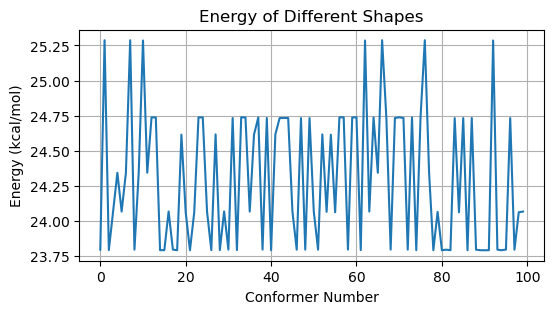

In [3]:
molecule = Chem.AddHs(molecule)  # Add hydrogens (needed for 3D structures)
AllChem.EmbedMultipleConfs(
    molecule, numConfs=100, params=AllChem.ETKDG()
)  # 10 conformers

energies = []
for conf_id in range(100):
    props = AllChem.MMFFGetMoleculeProperties(molecule)
    force_field = AllChem.MMFFGetMoleculeForceField(molecule, props, confId=conf_id)
    if force_field is not None:
        force_field.Minimize()  # Adjust to lowest energy
        energies.append(force_field.CalcEnergy())
    else:
        energies.append(float("nan"))  # Invalid conformers

plt.figure(figsize=(6, 3))
plt.plot(range(len(energies)), energies)
plt.xlabel("Conformer Number")
plt.ylabel("Energy (kcal/mol)")
plt.title("Energy of Different Shapes")
plt.grid(True)
plt.show()

In drug design, the lowest-energy shape might be the one that best fits a protein's binding site. The lowest and highest energy states are visualised below:

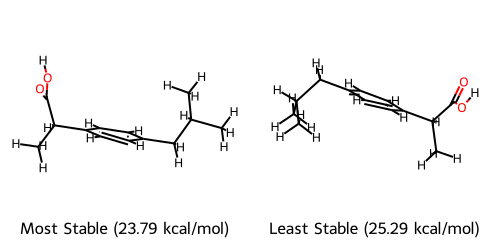

In [4]:
valid_energies = [e for e in energies if not pd.isna(e)]  # Ignore invalid
lowest_energy_idx = energies.index(min(valid_energies))
highest_energy_idx = energies.index(max(valid_energies))

conformer_ids = [lowest_energy_idx, highest_energy_idx]
labels = [
    f"Most Stable ({min(valid_energies):.2f} kcal/mol)",
    f"Least Stable ({max(valid_energies):.2f} kcal/mol)",
]
Draw.MolsToGridImage(
    [molecule, molecule],
    molsPerRow=2,
    subImgSize=(250, 250),
    legends=labels,
    confIds=conformer_ids,
)

## Impact!

### Alteoric uncertainty

Conformational flexibility can be a source of aleatoric uncertainty in molecular modeling, due to the probabilistic sampling fo conformers:

- Molecules explore many conformers (e.g., ~3^N for N rotatable bonds) due to thermal fluctuations.
- The bioactive conformer (the one that binds a protein) may not be the dominant one in solution, leading to variability in predictions (e.g., binding affinity or solubility in AQSolDB).

### Drug Binding

Binding to a protein requires a specific conformer, which may not be the lowest-energy one in solution, potentially resulting in:

- **Enthalpic Penalty ($\Delta H$):** If the bioactive conformer has higher energy (e.g., strained bonds), it costs energy to adopt it.
- **Entropic Penalty ($\Delta S$):** In solution, a flexible molecule samples many conformers, giving high entropy. Binding restricts it to one conformer, reducing entropy by:  
  $$
  \Delta S = -R \ln(\omega)
  $$
  where *R* is the gas constant (8.314 J/mol·K), and $\omega$ is the number of conformers (e.g., ~59,000 for 10 rotatable bonds, yielding $T\Delta S \approx 30$–$40$ kJ/mol at 298 K).

Gibbs free energy is:  
$$
\Delta G = \Delta H - T \Delta S
$$

Positive $\Delta H$ and negative $-T\Delta S$ make binding less favorable, reducing affinity. Rigid drugs (i.e., with low $\omega$) have smaller entropic penalties but may not fit diverse pockets.

### Solubility

In AQSolDB, solubility depends on how conformers interact with water. Flexible molecules might adopt polar-exposed conformers (improving solubility) or hydrophobic ones (reducing it). Aleatoric uncertainty crops up since the dominant conformer in solution varies, which affects hydration and solubility predictions.